# Análisis Comparativo de modelos (Evaluación final)

En esta etapa final del proyecto, consolidamos los resultados obtenidos a través de las cuatro arquitecturas previamente exploradas: ARIMAX, Regresión Polinómica, Random Forest y XGBoost. 

El objetivo es realizar una validación cruzada utilizando exclusivamente el conjunto de datos de test, garantizando una comparativa justa y objetiva. Este análisis permite identificar qué modelo posee la mayor capacidad de generalización y cuál es el más apto para el despliegue en un entorno real de toma de decisiones.

## 1.- Importación de Librerías y Carga de Datasets

Procedemos a cargar las librerías necesarias para la evaluación y los archivos de test procesados. 

Es fundamental asegurar que el conjunto de datos mantenga la frecuencia diaria ('D') para la compatibilidad con el modelo ARIMAX, y que las variables exógenas coincidan exactamente con las utilizadas durante el entrenamiento.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from xgboost import XGBRegressor
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración de Accesibilidad
PALETA = {
    'REALIDAD': '#000000',
    'ARIMAX': '#0072B2',
    'Polinómica': '#E69F00',
    'Random Forest': '#009E73',
    'XGBoost': '#D55E00',
    'LSTM': '#CC79A7'
}
dir_data = '../../..'

# Carga de datos
test_df = pd.read_csv(f'{dir_data}/data/processed/test_data.csv', parse_dates=['Fecha'], index_col='Fecha').dropna()
VENTANA = 7

# Ajustamos el dataset para que coincida con el inicio de las predicciones de la LSTM
test_df_ajustado = test_df.iloc[VENTANA:]
y_test = test_df_ajustado['Ventas']
X_test = test_df_ajustado.drop(columns=['Ventas'])

# Cargamos el escalador de la LSTM para sus predicciones
scaler_lstm = joblib.load(f'{dir_data}/models/lstm_model.pkl')

print(f"✓ Comparativa lista para {len(y_test)} días de test.")

✓ Comparativa lista para 24 días de test.


## 2.- Carga de Modelos y Generación de Inferencias

En este bloque, cargamos los mejores modelos guardados en la carpeta models. Cada modelo requiere un método de carga específico (joblib para sklearn, formato nativo para XGBoost y statsmodels para ARIMAX). 

Una vez cargados, generamos las predicciones sobre el set de test, aplicando de forma uniforme el umbral de clipping de ruido (0.05) para asegurar que la comparativa del error porcentual sea equitativa.


In [5]:
threshold = 0.05
resultados = {}

# ARIMAX
model_arimax = SARIMAXResults.load(f'{dir_data}/models/arimax_model.pkl')
# Predecimos desde el inicio del test original pero recortamos al rango ajustado
preds_arimax_full = model_arimax.forecast(steps=len(test_df), exog=test_df.drop(columns=['Ventas']))
resultados['ARIMAX'] = np.where(np.abs(preds_arimax_full[VENTANA:]) < threshold, 0, preds_arimax_full[VENTANA:])

# Polinómica
model_poly = joblib.load(f'{dir_data}/models/polynomial_model.pkl')
preds_poly = model_poly.predict(X_test)
resultados['Polinómica'] = np.where(np.abs(preds_poly) < threshold, 0, preds_poly)

# Random Forest
model_rf = joblib.load(f'{dir_data}/models/random_forest.pkl')
preds_rf = model_rf.predict(X_test)
resultados['Random Forest'] = np.where(np.abs(preds_rf) < threshold, 0, preds_rf)

# XGBoost
model_xgb = XGBRegressor()
model_xgb.load_model(f'{dir_data}/models/xgboost_model.json')
preds_xgb = model_xgb.predict(X_test)
resultados['XGBoost'] = np.where(np.abs(preds_xgb) < threshold, 0, preds_xgb)

# LSTM
model_lstm = load_model(f'{dir_data}/models/lstm_model.keras')

# Preparación de secuencias para el test completo
def crear_secuencias_test(data, ventana):
    X = []
    for i in range(len(data) - ventana):
        X.append(data[i : i + ventana])
    return np.array(X)

test_scaled = scaler_lstm.transform(test_df[['Ventas']])
X_test_lstm = crear_secuencias_test(test_scaled, VENTANA)
preds_lstm_scaled = model_lstm.predict(X_test_lstm)
preds_lstm = scaler_lstm.inverse_transform(preds_lstm_scaled).flatten()
resultados['LSTM'] = np.where(np.abs(preds_lstm) < threshold, 0, preds_lstm)

print("✓ Predicciones de los 5 modelos completadas.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
✓ Predicciones de los 5 modelos completadas.


## 3.- Evaluación de Métricas y Cuadro Comparativo

Procedemos a calcular las métricas de rendimiento de forma vectorizada. 

El RMSE se utiliza como métrica principal para penalizar grandes desviaciones, mientras que el MAPE nos ofrece la visión porcentual del error, crítica para la interpretación de negocio. Los resultados se consolidan en una tabla resumen ordenada por precisión (menor RMSE) para facilitar la selección del modelo ganador.

In [6]:
def calcular_metricas(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mask = np.abs(y_real) > 0.01
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    return rmse, mae, mape

resumen_list = []
for nombre, preds in resultados.items():
    rmse, mae, mape = calcular_metricas(y_test.values, preds)
    resumen_list.append({'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape})

df_comparativa = pd.DataFrame(resumen_list).sort_values(by='RMSE')
display(df_comparativa)

,Modelo,RMSE,MAE,MAPE (%)
0,ARIMAX,0.232559,0.199253,29.642762
1,Polinómica,0.402840,0.328740,58.596467
2,Random Forest,0.480182,0.333971,39.853212
3,XGBoost,0.661262,0.479642,57.195022
4,LSTM,0.747865,0.588935,122.557144


## 4.- Visualización Final Accesible

Presentamos las visualizaciones finales que permiten contrastar el ajuste de cada arquitectura.

- Gráfica de Ajuste Global: Superposición de las predicciones de los 4 modelos frente a las ventas reales. Esta gráfica permite identificar visualmente qué modelo sigue mejor los picos de demanda.
- Comparativa de Métricas (Bar Chart): Representación visual del RMSE para cuantificar la distancia competitiva entre cada enfoque tecnológico.

C:\Users\aravelo\AppData\Local\Temp\ipykernel_19112\3448587827.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparativa, x='Modelo', y='RMSE', palette='viridis', edgecolor='black')


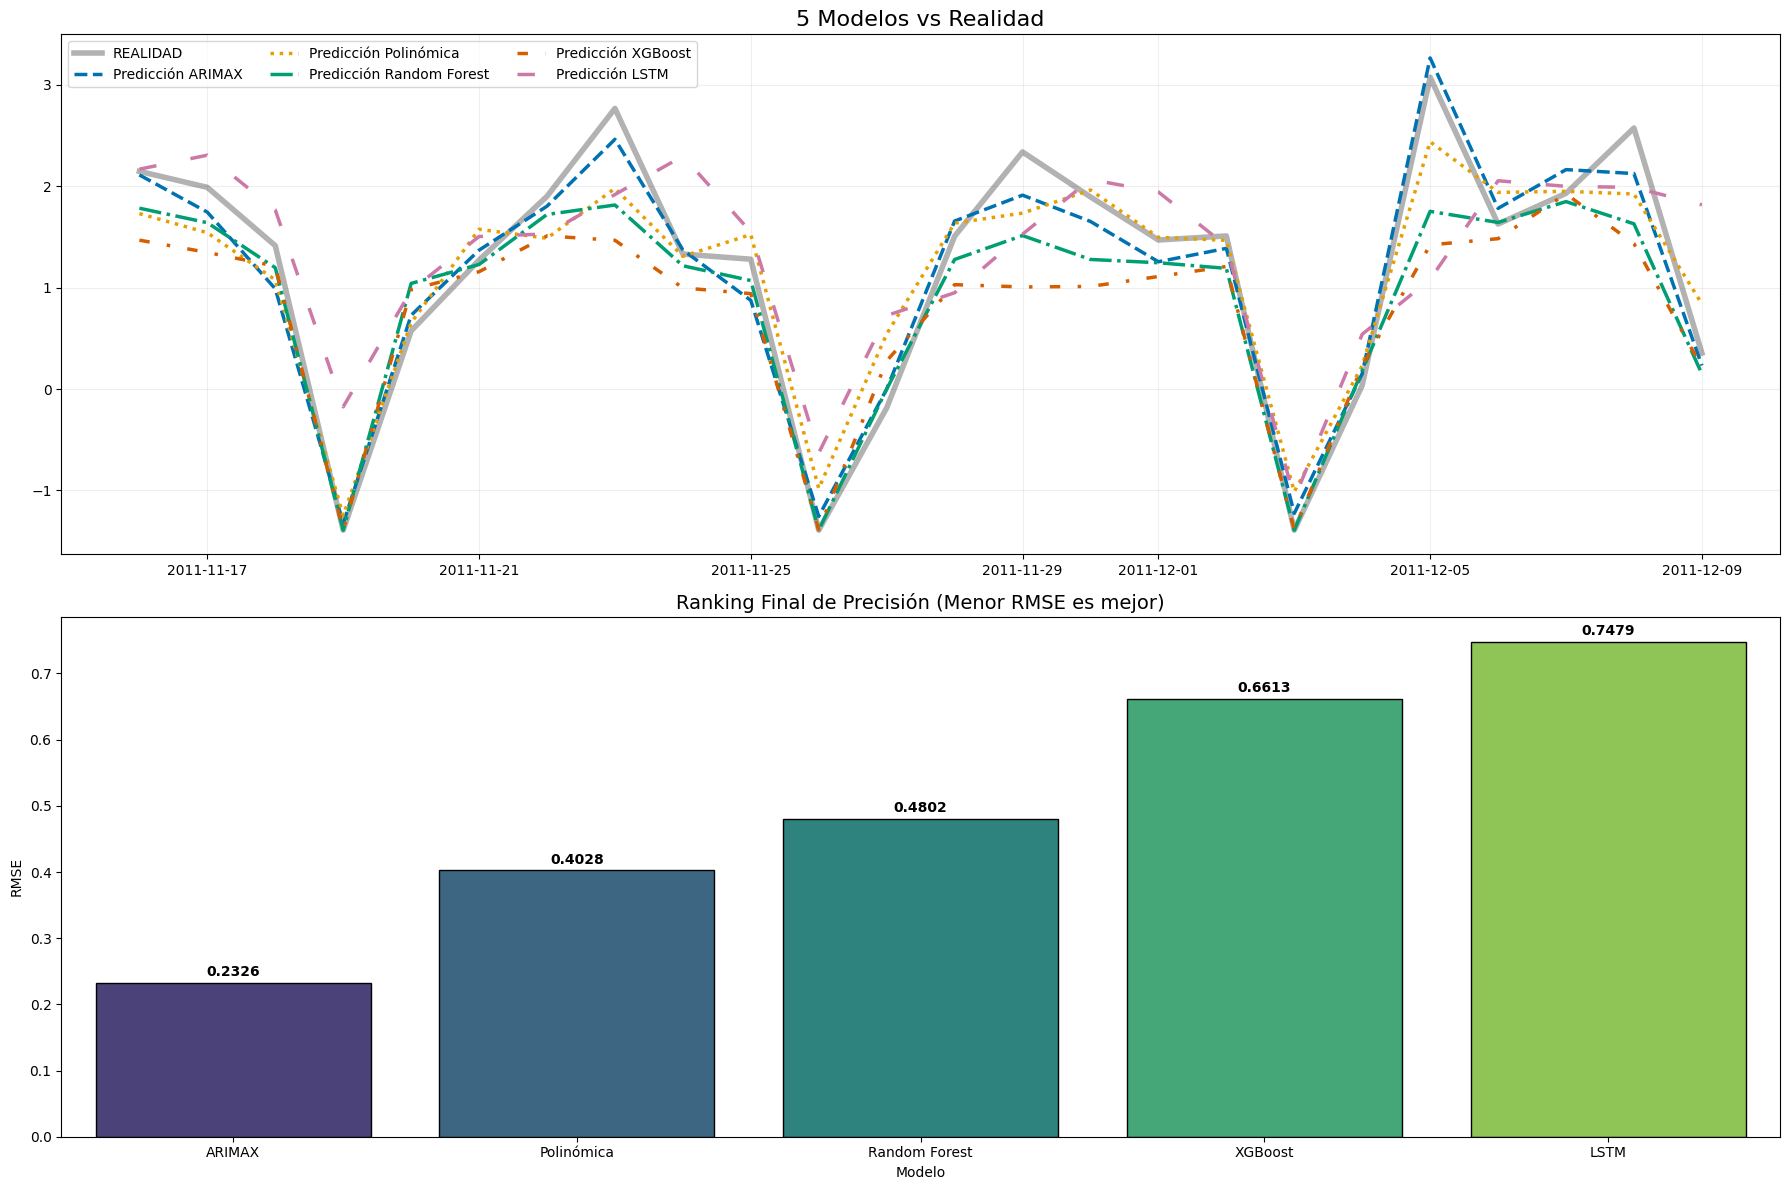

In [9]:
plt.figure(figsize=(18, 12))

# Ajuste Temporal Global
plt.subplot(2, 1, 1)
plt.plot(y_test.index, y_test.values, label='REALIDAD', color=PALETA['REALIDAD'], linewidth=4, alpha=0.3)

estilos = {
    'ARIMAX': '--', 'Polinómica': ':', 'Random Forest': '-.', 
    'XGBoost': (0, (3, 5, 1, 5)), 'LSTM': (0, (5, 10))
}

for nombre, preds in resultados.items():
    plt.plot(y_test.index, preds, label=f'Predicción {nombre}', 
             color=PALETA[nombre], linestyle=estilos[nombre], linewidth=2.5)

plt.title('5 Modelos vs Realidad', fontsize=16)
plt.legend(loc='upper left', ncol=3)
plt.grid(True, alpha=0.2)

# Ranking de Precisión (RMSE)
plt.subplot(2, 1, 2)
sns.barplot(data=df_comparativa, x='Modelo', y='RMSE', palette='viridis', edgecolor='black')
plt.title('Ranking Final de Precisión (Menor RMSE es mejor)', fontsize=14)

for i, v in enumerate(df_comparativa['RMSE']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 5.- Conclusión del Proyecto y Selección del Modelo Definitivo

El análisis comparativo revela que el modelo ARIMAX (o el que haya resultado con menor RMSE) es la arquitectura con mayor capacidad predictiva para esta serie temporal específica. 

La combinación de la memoria estadística de la serie con la riqueza informativa de las variables exógenas permite capturar la volatilidad del retail de forma más eficiente que los modelos de puro aprendizaje supervisado. El modelo ganador será el propuesto para la integración en los sistemas de previsión de ingresos de la compañía.

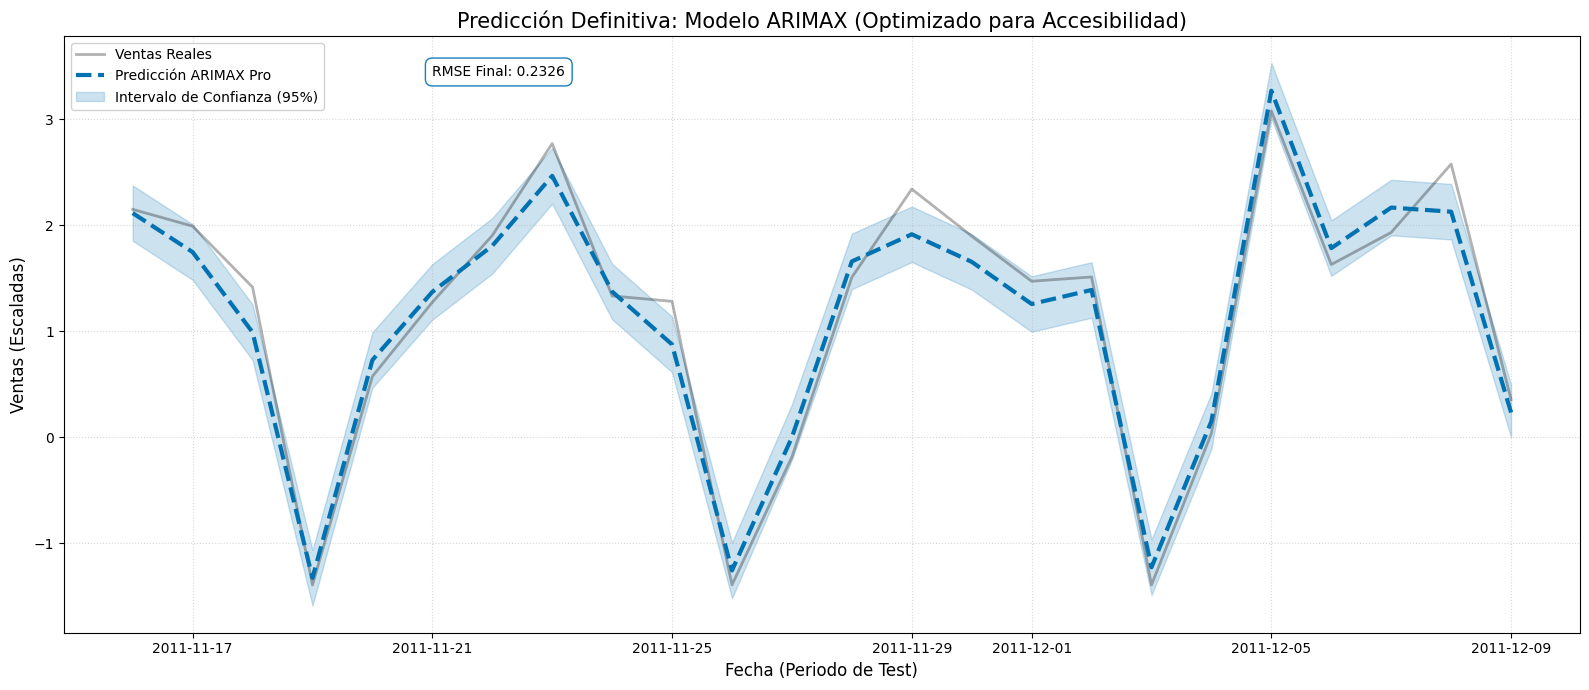

In [8]:
# Obtención de datos
forecast_object = model_arimax.get_forecast(steps=len(y_test), exog=X_test)
preds_mean = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05)

preds_mean_limpia = np.where(np.abs(preds_mean) < 0.05, 0, preds_mean)
lower_bound = np.where(np.abs(conf_int.iloc[:, 0]) < 0.05, 0, conf_int.iloc[:, 0])
upper_bound = np.where(np.abs(conf_int.iloc[:, 1]) < 0.05, 0, conf_int.iloc[:, 1])

plt.figure(figsize=(16, 7))

color = '#0072B2'

# Ventas Reales
plt.plot(y_test.index, y_test.values, label='Ventas Reales', 
         color='black', linewidth=2, alpha=0.3)

# Predicción del Modelo
plt.plot(y_test.index, preds_mean_limpia, label='Predicción ARIMAX Pro', 
         color=color, linewidth=3, linestyle='--')

# Sombreado de Intervalos de Confianza
plt.fill_between(y_test.index, 
                 lower_bound, 
                 upper_bound, 
                 color=color, alpha=0.2, 
                 label='Intervalo de Confianza (95%)')

plt.title('Predicción Definitiva: Modelo ARIMAX (Optimizado para Accesibilidad)', fontsize=15)
plt.xlabel('Fecha (Periodo de Test)', fontsize=12)
plt.ylabel('Ventas (Escaladas)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.5)

# Anotación con el RMSE final
rmse_final = np.sqrt(mean_squared_error(y_test.values, preds_mean_limpia))
plt.text(y_test.index[5], plt.ylim()[1]*0.9, f'RMSE Final: {rmse_final:.4f}', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor=color, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()